# B — Chondrite Endmember Compositions

This notebook establishes bulk compositions for four chondrite groups (**EH/EF, EL/EC, OC, CI**) and compares them with **Earth** and **Mars** bulk compositions.

**Key steps:**
1. Load meteorite and planetary mantle/core compositions from `ad.constants`
2. Compute compound molar masses using `MolarMassCalculator`
3. Convert weight percent (wt%) to molar amounts and normalize to MgO
4. Apply refractory element enrichment and volatile element depletion corrections for the EF endmember
5. Plot CI-chondrite-normalized element abundance diagrams (mantle vs. core)
6. Export normalized compositions to CSV

**Output:** `Tables/A2_Meteorites_composition.csv`

> **Prerequisites:** Ensure the `accrediff` package is available (located in `../../src/`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('../../src')
import accrediff as ad

# ── Plot style ──────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150,
})

# ── Color palette ───────────────────────────────────────
Colors = {
    'Earth': '#1f77b4',
    'Mars' : '#d62728',
    'EF'   : '#8c564b',
    'EC'   : '#ff7f0e',
    'OC'   : '#2ca02c',
    'CI'   : '#9467bd',
}

print('Setup complete.')

Setup complete.


In [2]:
# ── Load constants ───────────────────────────────────────
Elements = ad.constants.Elements

# Meteorite bulk compositions (wt%)
EF_bulk = ad.constants.EF_bulk
EC_bulk = ad.constants.EC_bulk
OC_bulk = ad.constants.OC_bulk
CI_bulk = ad.constants.CI_bulk

# Planetary bulk compositions (MgO-normalized molar ratios)
Earth_bulk_mg = ad.constants.Earth_bulk_mg
Mars_bulk_mg  = ad.constants.Mars_bulk_mg

# ── Compute molar masses for oxides & metals ─────────────
calc = ad.MolarMassCalculator(mass_table=Elements)
compounds = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2', 'Fe', 'Ni', 'Si', 'O']
for c in compounds:
    Elements[c] = calc.molar_mass(c)

# ── Define component groups ──────────────────────────────
mantle_items = ['MgO', 'Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_items   = ['Fe', 'Ni', 'Si', 'O']
bulk_items   = mantle_items + core_items

print('Molar masses (g/mol):')
pd.Series({c: Elements[c] for c in compounds}, name='M (g/mol)')

Molar masses (g/mol):


MgO       40.31
Al2O3    101.96
CaO       56.08
FeO       71.85
NiO       74.69
SiO2      60.09
Fe        55.85
Ni        58.69
Si        28.09
O         16.00
Name: M (g/mol), dtype: float64

---
## 1. Convert wt% → Molar Amounts

Molar amount for each component $i$:

$$n_i = \frac{w_i}{M_i}$$

where $w_i$ is the weight percent and $M_i$ is the molar mass (g/mol).  
Missing components are set to `0`.

In [4]:
def wt_to_molar(bulk_wt: dict, items: list, mass_table: dict) -> dict:
    """Convert weight percentages to molar amounts."""
    molar = {}
    for item in items:
        if item in bulk_wt and mass_table.get(item, 0) > 0:
            molar[item] = bulk_wt[item] / mass_table[item]
        else:
            molar[item] = 0.0
    return molar


EF_bulk_molar = wt_to_molar(EF_bulk, bulk_items, Elements)
EC_bulk_molar = wt_to_molar(EC_bulk, bulk_items, Elements)
OC_bulk_molar = wt_to_molar(OC_bulk, bulk_items, Elements)
CI_bulk_molar = wt_to_molar(CI_bulk, bulk_items, Elements)

df_molar = pd.DataFrame({
    'EF': EF_bulk_molar,
    'EC': EC_bulk_molar,
    'OC': OC_bulk_molar,
    'CI': CI_bulk_molar,
})

print('Molar amounts (mol per 100 g):')
df_molar

Molar amounts (mol per 100 g):


,EF,EC,OC,CI
MgO,0.649997,0.557706,0.589986,0.423083
Al2O3,0.034800,0.018611,0.021288,0.016779
CaO,0.050812,0.026425,0.031574,0.024499
FeO,0.000000,0.000000,0.294128,0.357028
NiO,0.000299,0.000285,0.000211,0.019465
SiO2,0.523541,0.663704,0.627254,0.410569
Fe,0.548516,0.501110,0.098043,0.000000
Ni,0.029609,0.028233,0.020903,0.000000
Si,0.107231,0.029822,0.000000,0.000000
O,0.000000,0.000000,0.000000,0.000000


---
## 2. Normalize to MgO

All molar amounts are divided by $n_{\text{MgO}}$ to yield dimensionless molar ratios:

$$\left(\frac{X}{\text{MgO}}\right) = \frac{n_i}{n_{\text{MgO}}}$$

In [5]:
def normalize_to_mgo(molar: dict) -> dict:
    """Normalize molar dict to MgO content."""
    mgo = molar['MgO']
    if mgo == 0:
        raise ValueError('MgO molar amount is zero; cannot normalize.')
    return {k: v / mgo for k, v in molar.items()}


EF_bulk_mg = normalize_to_mgo(EF_bulk_molar)
EC_bulk_mg = normalize_to_mgo(EC_bulk_molar)
OC_bulk_mg = normalize_to_mgo(OC_bulk_molar)
CI_bulk_mg = normalize_to_mgo(CI_bulk_molar)

df_mg = pd.DataFrame({
    'EF': EF_bulk_mg,
    'EC': EC_bulk_mg,
    'OC': OC_bulk_mg,
    'CI': CI_bulk_mg,
})

print('MgO-normalized molar ratios:')
df_mg

MgO-normalized molar ratios:


,EF,EC,OC,CI
MgO,1.000000,1.000000,1.000000,1.000000
Al2O3,0.053539,0.033370,0.036082,0.039658
CaO,0.078172,0.047382,0.053517,0.057905
FeO,0.000000,0.000000,0.498534,0.843874
NiO,0.000460,0.000511,0.000358,0.046009
SiO2,0.805451,1.190060,1.063167,0.970423
Fe,0.843874,0.898519,0.166178,0.000000
Ni,0.045552,0.050623,0.035430,0.000000
Si,0.164972,0.053472,0.000000,0.000000
O,0.000000,0.000000,0.000000,0.000000


---
## 3. Apply Enrichment / Depletion Corrections to EF

Refractory-enriched (**EF**) meteorites are characterized by:
- **Refractory enrichment**: Al₂O₃ and CaO are enriched relative to CI (×1.5)
- **Volatile depletion**: SiO₂ (mantle) and Si (core) are depleted (×0.6)

These corrections are applied to the MgO-normalized values.

In [6]:
# Enrichment & depletion factors
ENRICH_FACTOR  = 1.5   # Refractory elements (Al2O3, CaO)
DEPLETE_FACTOR = 0.6   # Volatile element (Si)

# Apply to EF
EF_bulk_mg['Al2O3'] = CI_bulk_mg['Al2O3'] * ENRICH_FACTOR
EF_bulk_mg['CaO']   = CI_bulk_mg['CaO']   * ENRICH_FACTOR
EF_bulk_mg['SiO2'] *= DEPLETE_FACTOR
EF_bulk_mg['Si']   *= DEPLETE_FACTOR

print(f'Al2O3 enrichment : CI × {ENRICH_FACTOR}')
print(f'CaO   enrichment : CI × {ENRICH_FACTOR}')
print(f'SiO2  depletion  : EF × {DEPLETE_FACTOR}')
print(f'Si    depletion  : EF × {DEPLETE_FACTOR}')
print()

pd.DataFrame({'EF_corrected': EF_bulk_mg})

Al2O3 enrichment : CI × 1.5
CaO   enrichment : CI × 1.5
SiO2  depletion  : EF × 0.6
Si    depletion  : EF × 0.6



,EF_corrected
MgO,1.000000
Al2O3,0.059488
CaO,0.086858
FeO,0.000000
NiO,0.000460
SiO2,0.483270
Fe,0.843874
Ni,0.045552
Si,0.098983
O,0.000000


---
## 4. CI-Chondrite Normalization

To enable cross-system comparison, compositions are doubly normalized to **Mg** and **CI chondrites**:

$$\left(\frac{X}{\text{Mg}}\right)_{\text{CI}} = \frac{(X/\text{MgO})_{\text{system}}}{(X/\text{MgO})_{\text{CI}}}$$

- **Mantle elements**: Al, Ca, Fe, Ni, Si via their oxides
- **Core elements**: Fe, Ni, Si — normalized against corresponding mantle oxides in CI (FeO, NiO, SiO₂)

In [7]:
# All systems to compare
systems = {
    'Earth': Earth_bulk_mg,
    'Mars' : Mars_bulk_mg,
    'EF'   : EF_bulk_mg,
    'EC'   : EC_bulk_mg,
    'OC'   : OC_bulk_mg,
    'CI'   : CI_bulk_mg,
}

# Mantle normalization: oxide_i / CI_oxide_i
mantle_CI = {}
for name, comp in systems.items():
    mantle_CI[name] = {item: comp[item] / CI_bulk_mg[item]
                       for item in mantle_items}

# Core normalization: metal_i / CI_oxide_j
# Mapping: Fe→FeO, Ni→NiO, Si→SiO2
core_oxide_map = {'Fe': 'FeO', 'Ni': 'NiO', 'Si': 'SiO2'}

core_CI = {}
for name, comp in systems.items():
    core_CI[name] = {metal: comp[metal] / CI_bulk_mg[oxide]
                     for metal, oxide in core_oxide_map.items()}

print('Mantle CI-normalized (Earth):')
print({k: f"{v:.3f}" for k, v in mantle_CI['Earth'].items()})
print()
print('Core   CI-normalized (Earth):')
print({k: f"{v:.3f}" for k, v in core_CI['Earth'].items()})

Mantle CI-normalized (Earth):
{'MgO': '1.000', 'Al2O3': '1.171', 'CaO': '1.163', 'FeO': '0.142', 'NiO': '0.078', 'SiO2': '0.821'}

Core   CI-normalized (Earth):
{'Fe': '0.940', 'Ni': '0.978', 'Si': '0.076'}


---
## 5. CI-Normalized Spider Diagram

Plot element abundance patterns normalized to Mg and CI chondrites.
- **Squares** (■): mantle phases (oxides)
- **Circles** (●): core phases (metals)

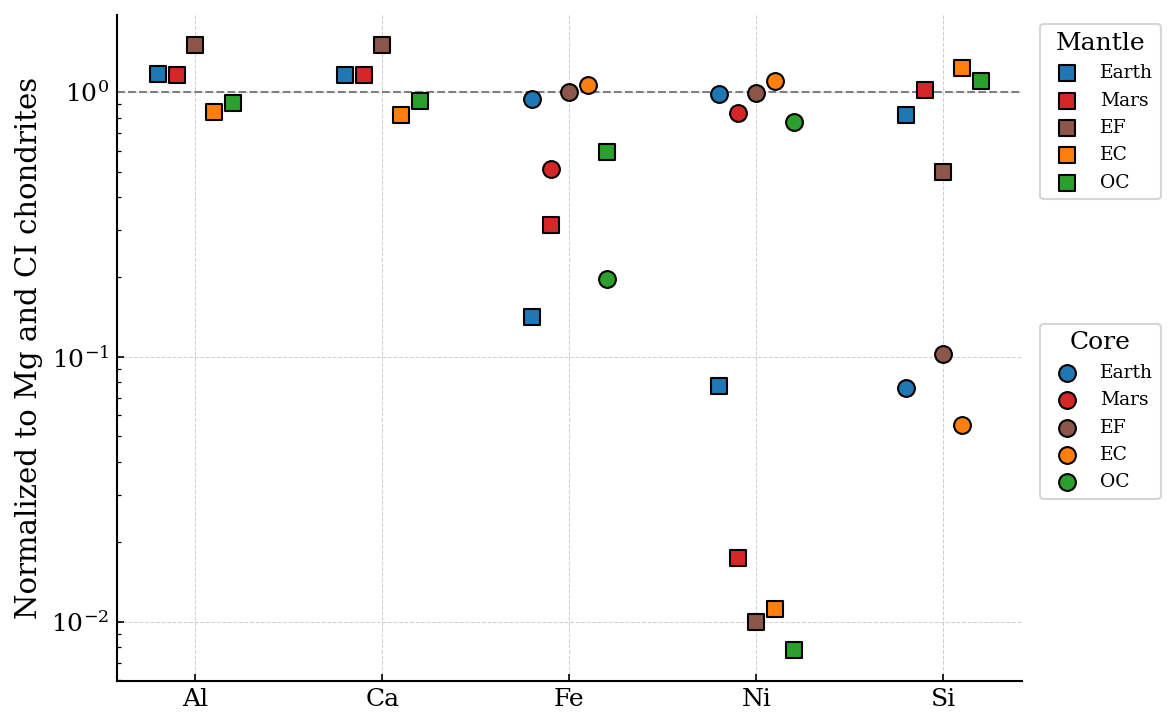

In [9]:
# Axis setup
elements    = ['Al', 'Ca', 'Fe', 'Ni', 'Si']
mantle_keys = ['Al2O3', 'CaO', 'FeO', 'NiO', 'SiO2']
core_keys   = ['Fe', 'Ni', 'Si']
x_idx       = np.arange(len(elements))   # [0, 1, 2, 3, 4]
xx_idx      = np.array([2, 3, 4])        # Fe, Ni, Si positions

plot_names = ['Earth', 'Mars', 'EF', 'EC', 'OC']

fig, ax = plt.subplots(figsize=(8, 5))

# ── Mantle (squares) ─────────────────────────────────────
offsets_m = np.linspace(-0.2, 0.2, len(plot_names))
handles_mantle = []
for offset, name in zip(offsets_m, plot_names):
    y = [mantle_CI[name][k] for k in mantle_keys]
    sc = ax.scatter(x_idx + offset, y, color=Colors[name],
                    marker='s', s=65, edgecolor='k', zorder=3)
    handles_mantle.append(sc)

# ── Core (circles) ───────────────────────────────────────
offsets_c = np.linspace(-0.2, 0.2, len(plot_names))
handles_core = []
for offset, name in zip(offsets_c, plot_names):
    y = [core_CI[name][k] for k in core_keys]
    sc = ax.scatter(xx_idx + offset, y, color=Colors[name],
                    marker='o', s=65, edgecolor='k', zorder=3)
    handles_core.append(sc)

# ── Formatting ───────────────────────────────────────────
ax.set_yscale('log')
ax.set_xticks(x_idx)
ax.set_xticklabels(elements)
ax.set_ylabel('Normalized to Mg and CI chondrites')
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.grid(True, which='major', ls='--', lw=0.5, alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Grouped legends ──────────────────────────────────────
leg1 = ax.legend(handles_mantle, plot_names, title='Mantle',
                 bbox_to_anchor=(1.01, 1.0), loc='upper left', fontsize=9)
ax.add_artist(leg1)
ax.legend(handles_core, plot_names, title='Core',
          bbox_to_anchor=(1.01, 0.55), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## 6. Export to CSV

Save the MgO-normalized molar compositions for all four chondrite endmembers.

In [10]:
os.makedirs('./Tables', exist_ok=True)

df_export = pd.DataFrame({
    'EF': EF_bulk_mg,
    'EC': EC_bulk_mg,
    'OC': OC_bulk_mg,
    'CI': CI_bulk_mg,
}).fillna(0)

save_path = './Tables/A2_Meteorites_composition.csv'
df_export.to_csv(save_path, index=True)

print(f'Exported → {save_path}')
df_export

Exported → ./Tables/A2_Meteorites_composition.csv


,EF,EC,OC,CI
MgO,1.000000,1.000000,1.000000,1.000000
Al2O3,0.059488,0.033370,0.036082,0.039658
CaO,0.086858,0.047382,0.053517,0.057905
FeO,0.000000,0.000000,0.498534,0.843874
NiO,0.000460,0.000511,0.000358,0.046009
SiO2,0.483270,1.190060,1.063167,0.970423
Fe,0.843874,0.898519,0.166178,0.000000
Ni,0.045552,0.050623,0.035430,0.000000
Si,0.098983,0.053472,0.000000,0.000000
O,0.000000,0.000000,0.000000,0.000000


---
## 7. Summary

| Step | Operation | Output |
|:----:|-----------|--------|
| 0 | Load constants & compute molar masses | `Elements`, `*_bulk` |
| 1 | wt% → molar amounts | `*_bulk_molar` |
| 2 | Normalize to MgO | `*_bulk_mg` |
| 3 | EF enrichment / depletion corrections | Updated `EF_bulk_mg` |
| 4 | Double normalization (Mg & CI) | `mantle_CI`, `core_CI` |
| 5 | CI-normalized spider diagram | `Figures/B_CI_normalized_spider.pdf` |
| 6 | Export to CSV | `Tables/A2_Meteorites_composition.csv` |

The corrected MgO-normalized compositions (`*_bulk_mg`) and CI-normalized dicts (`mantle_CI`, `core_CI`) serve as endmember inputs for subsequent mixing and accretion notebooks.